In [ ]:
https://www.kaggle.com/datasets/ashydv/advertising-dataset

In [ ]:
# scikit-learn 설치 및 버전 확인
# %pip install scikit-learn

import sklearn
sklearn.__version__

'1.5.2'

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import warnings
# warnings.filterwarnings("ignore")
# plt.style.use('ggplot')

In [5]:
import pandas as pd

# TODO: advertising.csv 파일을 읽어와서 5개의 레코드를 출력
advertising = pd.read_csv('data/advertising.csv')
# TODO 2
advertising.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [6]:
# TODO: 데이터프레임 정보 확인하기
advertising.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [7]:
# TODO: 통계정보 확인하기
advertising.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [8]:
# TODO: 통계 정보 행과 열 바꾸기
advertising.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,15.1305,5.283892,1.6,11.000,16.00,19.050,27.0


In [9]:
# TODO: 컬럼간의 상관계수 확인하기
advertising.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


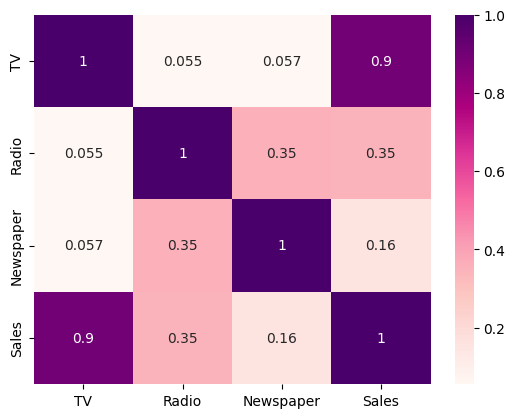

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

corrMatrix = advertising.corr()
sns.heatmap(corrMatrix, annot=True, cmap='RdPu')
plt.show()

In [13]:
# 히트맵을 기준으로 상관 관계가 높은 속성을 내림 차순으로 정렬하여 시각화

corr_sort = corrMatrix[['Sales']].sort_values(by='Sales', ascending= False)
corr_sort

,Sales
Sales,1.000000
TV,0.901208
Radio,0.349631
Newspaper,0.157960


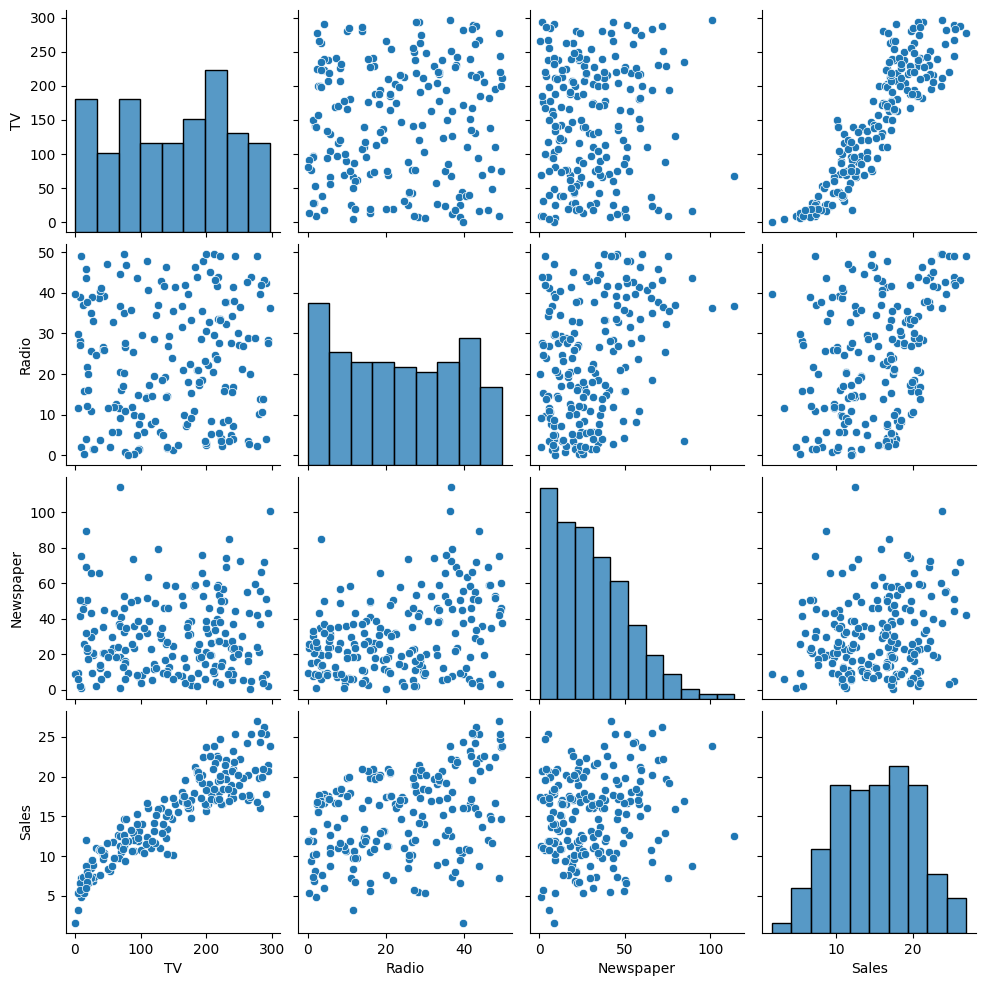

In [14]:
sns.pairplot(advertising)
plt.show()

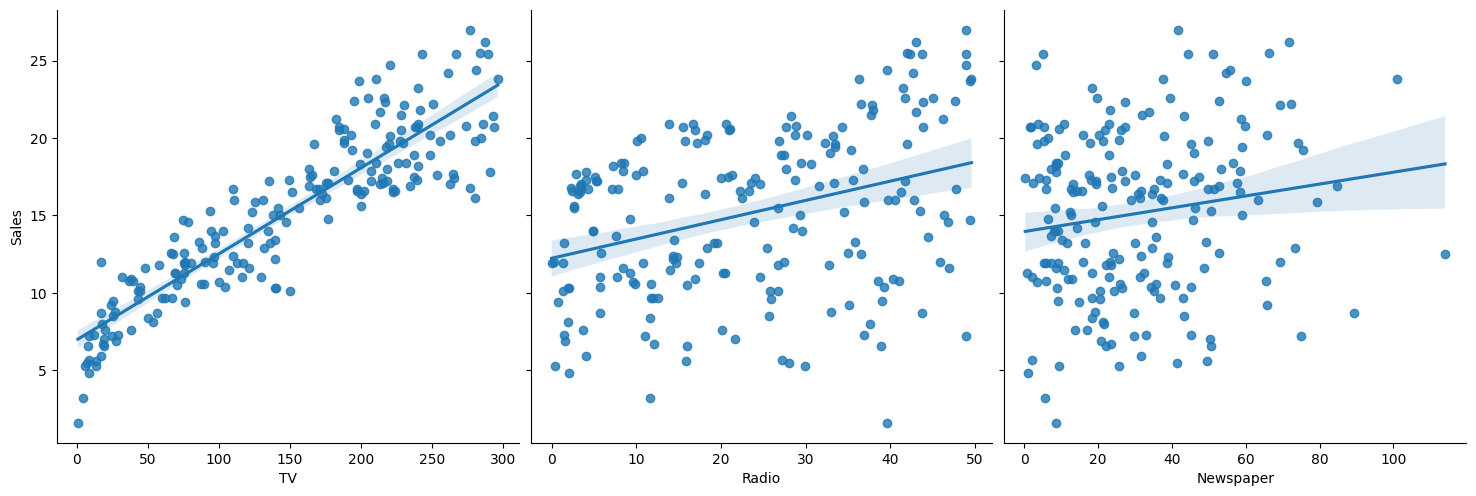

In [15]:
# 'TV', 'Radio', 'Newspaper'의 판매량 pairplot의 세개의 그래프만 그리면서 산점도와 함께 선형회귀선 포함하여 시각화하기

sns.pairplot(data=advertising, height=5, x_vars=['TV', 'Radio', 'Newspaper'], y_vars = 'Sales', kind = 'reg') #TODO:YOUR_CODE_HERE
plt.show()

### 단순 선형 회귀

In [16]:
# 단순 선형 회귀로 모델 학습하고 평가하기
advertising

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [ ]:
#독립변수로 TV 컬럼만 가져온다.
X_data1 = advertising[['TV']]  # TODO:YOUR_CODE_HERE

#종속변수로 Sales 데이터를 가져온다
y_data1 = advertising['Sales']  # TODO:YOUR_CODE_HERE

In [22]:
type(y_data1)

pandas.Series

In [23]:
# 훈련 데이터와 테스트 데이터를 7:3 비율로 나누기, random_state = 42
from sklearn.model_selection import train_test_split

X_train1, X_test1, y_train1, y_test1 = train_test_split(X_data1, y_data1, test_size=0.3, random_state = 42)
print(X_train1.shape, X_test1.shape, y_train1.shape, y_test1.shape)

(140, 1) (60, 1) (140,) (60,)


In [30]:
from sklearn.linear_model import LinearRegression

lr_model1 =  LinearRegression()
# 선형 회귀 모델 생성 TODO:YOUR_CODE_HERE
# 선형 회귀 모델 학습 TODO:YOUR_CODE_HERE

In [31]:
lr_model1

LinearRegression()

In [32]:
lr_model1.fit(X_train1, y_train1)

LinearRegression()

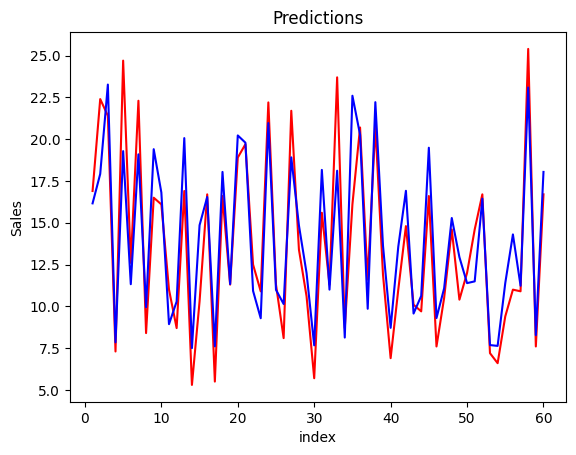

In [33]:
y_pred1 = lr_model1.predict(X_test1)

c = [i for i in range(1, 61, 1)]
plt.plot(c, y_test1, color = 'r') # 실젯값
plt.plot(c, y_pred1, color = 'b') # 예측값
plt.xlabel('index') # X축 이름
plt.ylabel('Sales') # Y축 이름
plt.title('Predictions') # 그래프 제목
plt.show()

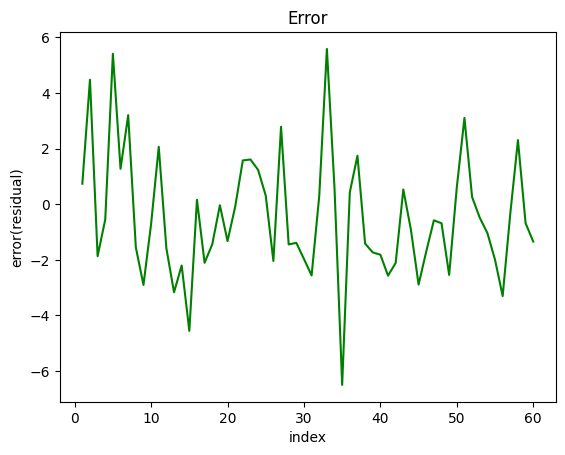

In [34]:
error = y_test1 - y_pred1 # 실젯값 - 예측값 TODO:YOUR_CODE_HERE

plt.plot(c, error, color = 'g')
plt.xlabel('index')
plt.ylabel('error(residual)')
plt.title('Error')
plt.show()

In [ ]:
# 평가 지표 구하기

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print(f'MSE: {mean_squared_error(y_test1, y_pred1):.2f}') # 평균 제곱 오차(MSE)
print(f'r2_score: {r2_score(y_test1, y_pred1):.2f}') # 결정계수(R2)

MSE: 5.18
r2_score: 0.81


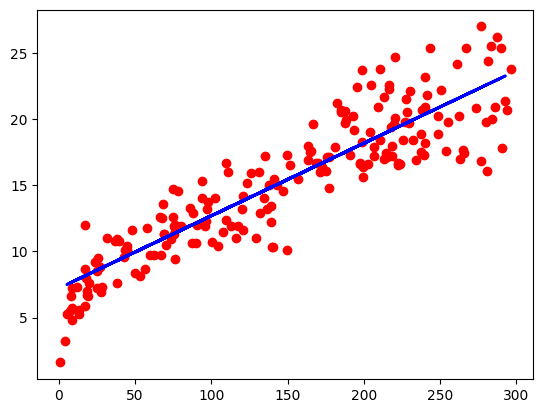

In [36]:
plt.scatter(X_data1, y_data1, color = 'red', label = 'scatter plot')
plt.plot(X_test1, y_pred1, color = 'blue', linewidth = 2, label = 'Regression Line')
plt.show()

In [37]:
# Slope Coefficients(기울기 계수)
w1 = lr_model1.coef_ # 기울기
print(f'slopes of TV: {w1[0]:.2f}')

# Intercept(절편)
b1 = lr_model1.intercept_ # y 절편
print('Intercept is:', b1.round(2))

slopes of TV: 0.05
Intercept is: 7.21


In [38]:
# 0.05 * TV + 7.21

lr_model1.coef_[0] * 100 + lr_model1.intercept_

np.float64(12.69004292770119)

In [ ]:
# 새로운 TV광고비를 입력받아 값 예측하기

100(1000달러) TV 광고비를 투자하면 얼마만큼의 판매량을 기대할 수 있을까요? 

### 다중 선형 회귀

In [43]:
# 타겟과 속성 분리하기
# X_data2 = advertising[['TV', 'Radio', 'Newspaper']] # TODO:YOUR_CODE_HERE
X_data2 = advertising.drop(['Sales'],axis=1)
y_data2 = advertising['Sales'] # TODO:YOUR_CODE_HERE

In [44]:
X_data2

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


<Axes: >

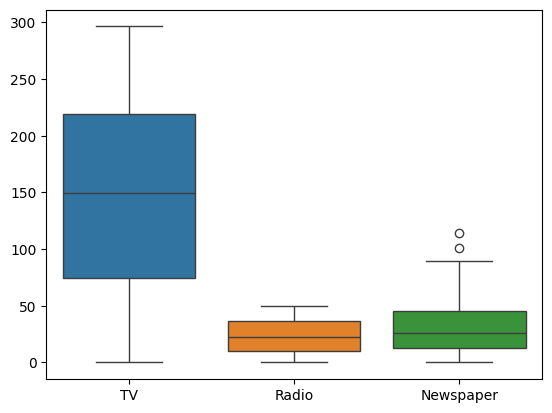

In [45]:
sns.boxplot(X_data2)

In [ ]:
# 훈련 데이터와 테스트 데이터를 7:3으로 나누기
# random_state 옵션을 사용하여 훈련 데이터와 테스트 데이터를 동일한 패턴으로 추출하기

In [46]:
from sklearn.model_selection import train_test_split

# TODO:YOUR_CODE_HERE
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_data2, y_data2, test_size=0.3, random_state = 42)
print(X_train2.shape, X_test2.shape, y_train2.shape, y_test2.shape)

(140, 3) (60, 3) (140,) (60,)


In [ ]:
# 속성값의 차이가 있으므로 범위를 일정하게 맞춰 주는 표준화 적용하기

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # TODO:YOUR_CODE_HERE

X_train_scaled = scaler.fit_transform(X_train2)  # TODO:YOUR_CODE_HERE
X_test_scaled = scaler.transform(X_test2)  # TODO:YOUR_CODE_HERE

In [ ]:
X_train_scaled

<Axes: >

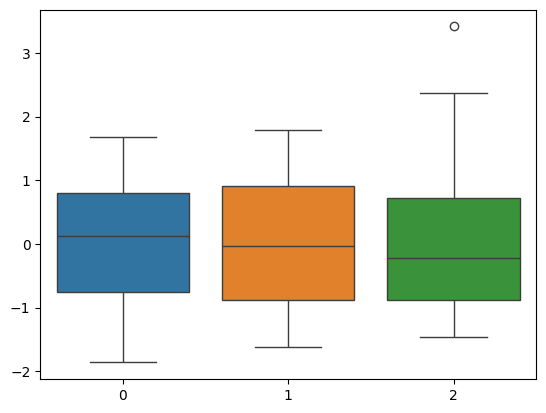

In [49]:
sns.boxplot(X_train_scaled)

In [ ]:
# 모델 생성하고 학습시키기

In [50]:
from sklearn.linear_model import LinearRegression

lr_model2 = LinearRegression() # TODO:YOUR_CODE_HERE
lr_model2.fit(X_train_scaled, y_train2) # TODO:YOUR_CODE_HERE

LinearRegression()

In [ ]:
# 실제값과 예측값을 구해 데이터프레임 형태로 만들기

In [ ]:
mlr = pd.DataFrame({'Actual_value': y_test2, 'Model prediction':lr_model2.predict(X_train_scaled)})
mlr.head()

In [ ]:
# 실제값과 예측값의 오차를 그래프로 표현

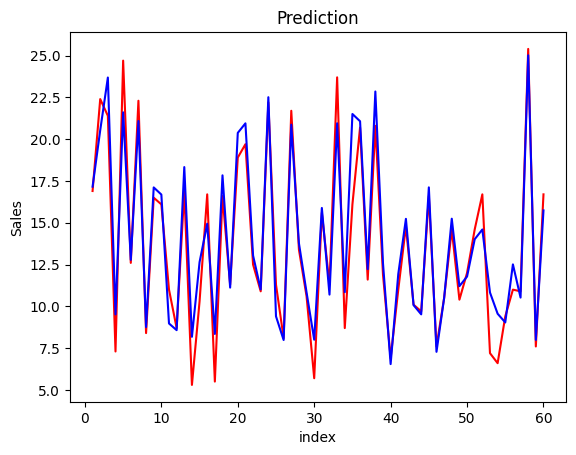

In [52]:
y_pred2 = lr_model2.predict(X_test_scaled)
c = [i for i in range(1, 61, 1)]

plt.plot(c, y_test2, color = 'r')
plt.plot(c, y_pred2, color ='b')
plt.xlabel('index')
plt.ylabel('Sales')
plt.title('Prediction')
plt.show()

In [ ]:
# 오차 그래프로 시각화하기

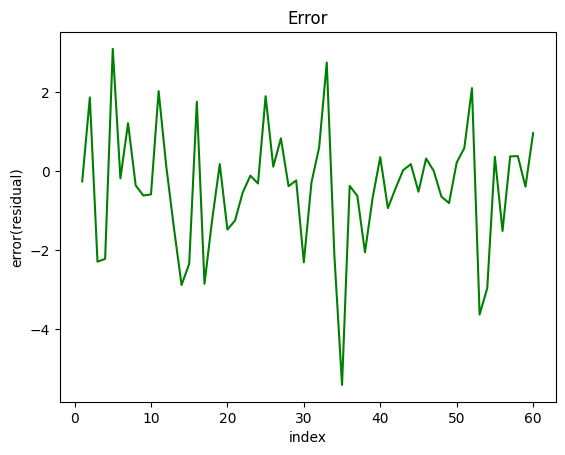

In [53]:
error2 = y_test2 - y_pred2 # TODO:YOUR_CODE_HERE
plt.plot(c, error2, color ='g')
plt.xlabel('index')
plt.ylabel('error(residual)')
plt.title('Error')
plt.show()

In [54]:
print(f'MSE:{mean_squared_error(y_test2, y_pred2):.2f}')
print(f'r2_score:{r2_score(y_test2, y_pred2):.2f}')

MSE:2.54
r2_score:0.91


In [ ]:
lr_model1.coef_[0] * 100 + lr_model1.intercept_

In [55]:
lr_model2.coef_

array([4.47999622, 1.49779488, 0.16358735])

In [56]:
# 기울기 계수
w2 = lr_model2.coef_ # TODO:YOUR_CODE_HERE
print(f'slopes of TV:{w2[0]:.2f}')
print(f'slopes of Radio:{w2[1]:.2f}')
print(f'slopes of Newspaper:{w2[2]:.2f}')

# 절편
b2 = lr_model2.intercept_ # TODO:YOUR_CODE_HERE
print('Intercept is:', b2.round(2))

slopes of TV:4.48
slopes of Radio:1.50
slopes of Newspaper:0.16
Intercept is: 15.78


In [62]:
# 새로운 값 예측하기 [[180,18,3]]
new_data = scaler.transform([[180,18,3]])
lr_model2.predict(new_data)

c:\Users\chrisLin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([16.26224796])

In [ ]:
np.float64(12.69004292770119)

### 다항회귀

In [68]:
X_data2 = advertising.drop(['Sales'],axis=1)
y_data2 = advertising['Sales'] # TODO:YOUR_CODE_HERE

In [69]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_data2, y_data2, test_size=0.3, random_state = 42)
print(X_train2.shape, X_test2.shape, y_train2.shape, y_test2.shape)

(140, 3) (60, 3) (140,) (60,)


In [72]:
# 다항회귀
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
x_train_poly = poly.fit_transform(X_train2)
x_test_poly = poly.transform(X_test2)

<Axes: >

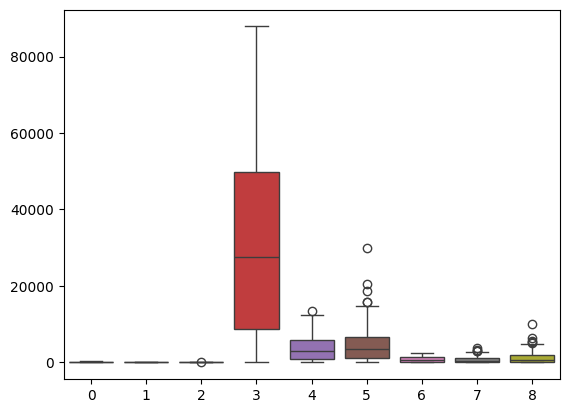

In [73]:
sns.boxplot(x_train_poly)

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # TODO:YOUR_CODE_HERE

X_train_poly_scaled = scaler.fit_transform(x_train_poly)  # TODO:YOUR_CODE_HERE
X_test_poly_scaled = scaler.transform(x_test_poly)  # TODO:YOUR_CODE_HERE

<Axes: >

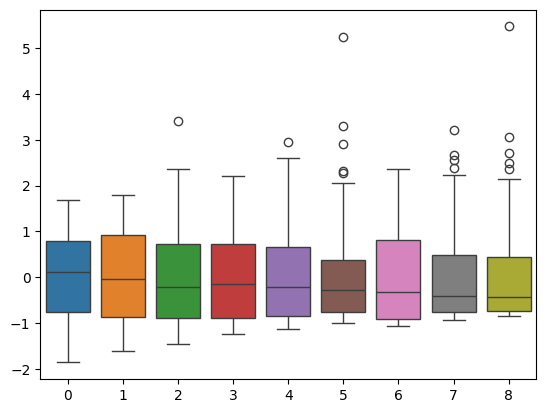

In [75]:
sns.boxplot(X_train_poly_scaled)

In [76]:
from sklearn.linear_model import LinearRegression

lr_model3 = LinearRegression() # TODO:YOUR_CODE_HERE
lr_model3.fit(X_train_poly_scaled, y_train2) # TODO:YOUR_CODE_HERE

LinearRegression()

In [77]:
pred = lr_model3.predict(X_test_poly_scaled)

In [79]:
print(f'MSE:{mean_squared_error(y_test2, pred):.2f}')
print(f'r2_score:{r2_score(y_test2, pred):.2f}')

MSE:1.50
r2_score:0.95


In [ ]:
MSE: 5.18
r2_score: 0.81

MSE:2.54
r2_score:0.91

MSE:1.50
r2_score:0.95

### 규제

In [ ]:
# 규제